
# Distributed DBSCAN (Spark-style) — Visual Walkthrough (matches your Java pipeline)

This notebook is **visual-first** and follows your Java code stages:

1) Load points  
2) Build grid  
3) Assign points to **home cell** + replicate **ghost points**  
4) Group by cell (each cell works independently)  
5) Run **local DBSCAN per cell**  
6) Group by point-id (find duplicates across cells)  
7) Build merge edges between local clusters  
8) Connected components (global merging)  
9) Assign final global clusters to **home points only** (ghosts removed)

You can switch datasets to show different behaviors:
- Cluster crossing a boundary (forces merging)
- Two clusters + noise
- Corner-touching (diagonal ghosts)


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict

plt.rcParams["figure.figsize"] = (9, 8)
plt.rcParams["axes.grid"] = False



## Step 0 — Choose a dataset

These are tiny datasets designed to **force** the behaviors you need to explain.

- **A_bridge_cluster**: One cluster crosses a boundary → ghost copies → merge edges → one global cluster
- **B_two_clusters_noise**: Two clusters and some noise → shows not everything merges
- **C_corner_touch**: Corner-touching → shows diagonal ghosts


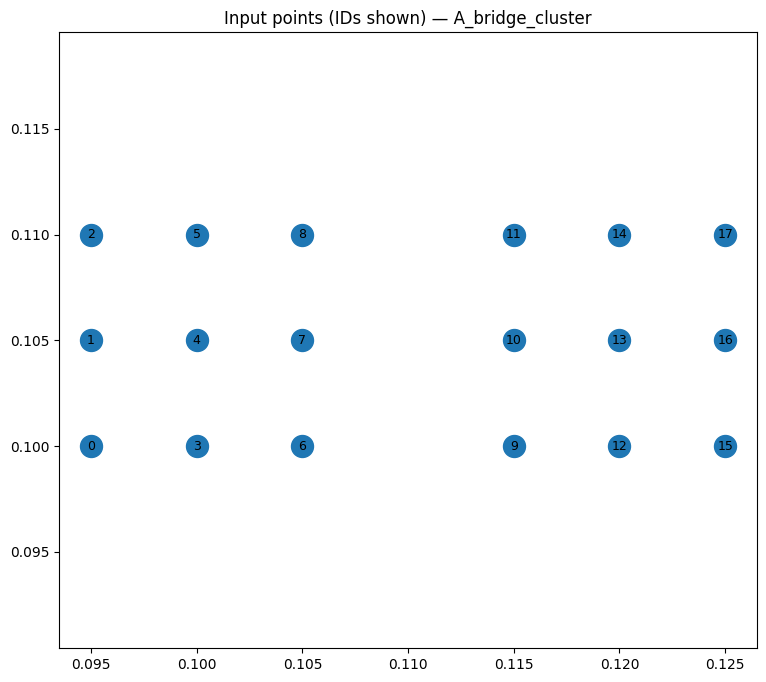

In [2]:

def make_dataset_A_bridge_cluster():
    # Cluster crosses a vertical boundary around x ~ 0.11
    pts = []
    pid = 0
    # left side of boundary
    for x in [0.095, 0.100, 0.105]:
        for y in [0.100, 0.105, 0.110]:
            pts.append((pid, x, y)); pid += 1
    # right side of boundary (same cluster continues)
    for x in [0.115, 0.120, 0.125]:
        for y in [0.100, 0.105, 0.110]:
            pts.append((pid, x, y)); pid += 1
    return np.array(pts, dtype=float)

def make_dataset_B_two_clusters_noise():
    pts = []
    pid = 0
    # cluster 1
    for x in [0.06, 0.065, 0.07]:
        for y in [0.06, 0.065, 0.07]:
            pts.append((pid, x, y)); pid += 1
    # cluster 2
    for x in [0.22, 0.225, 0.23]:
        for y in [0.22, 0.225, 0.23]:
            pts.append((pid, x, y)); pid += 1
    # noise
    for (x, y) in [(0.02, 0.24), (0.26, 0.05), (0.15, 0.02), (0.28, 0.28)]:
        pts.append((pid, x, y)); pid += 1
    return np.array(pts, dtype=float)

def make_dataset_C_corner_touch():
    # cluster near corner of a cell so diagonal ghost replication is visible
    pts = []
    pid = 0
    for x in [0.095, 0.100, 0.105, 0.110]:
        for y in [0.195, 0.200, 0.205]:
            pts.append((pid, x, y)); pid += 1
    return np.array(pts, dtype=float)

DATASETS = {
    "A_bridge_cluster": make_dataset_A_bridge_cluster,
    "B_two_clusters_noise": make_dataset_B_two_clusters_noise,
    "C_corner_touch": make_dataset_C_corner_touch,
}

dataset_name = "A_bridge_cluster"  # <-- change this
points = DATASETS[dataset_name]()

plt.figure()
plt.scatter(points[:,1], points[:,2], s=250)
for pid, x, y in points:
    plt.text(x, y, str(int(pid)), ha="center", va="center", fontsize=9)
plt.title(f"Input points (IDs shown) — {dataset_name}")
plt.axis("equal")
plt.show()



## Step 1 — Build the grid (PartitionConfiguration)

This is the grid your code creates from min/max bounds.


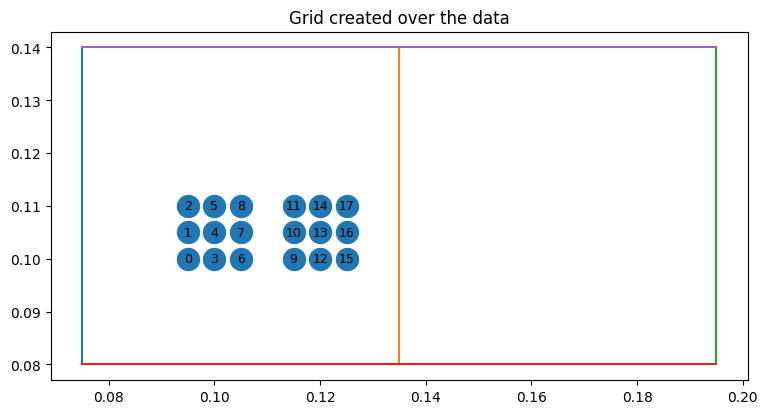

In [3]:

class PartitionConfiguration:
    def __init__(self, min_x, max_x, min_y, max_y, cell_size, buffer_size):
        self.min_x = float(min_x)
        self.max_x = float(max_x)
        self.min_y = float(min_y)
        self.max_y = float(max_y)
        self.cellSize = float(cell_size)
        self.buffer = float(buffer_size)

        self.numCellsX = int(math.floor((self.max_x - self.min_x) / self.cellSize)) + 1
        self.numCellsY = int(math.floor((self.max_y - self.min_y) / self.cellSize)) + 1

def cell_id(cfg, cx, cy):
    return cy * cfg.numCellsX + cx

def draw_grid(cfg, ax=None):
    if ax is None:
        ax = plt.gca()
    # vertical
    for i in range(cfg.numCellsX + 1):
        x = cfg.min_x + i*cfg.cellSize
        ax.plot([x,x], [cfg.min_y, cfg.min_y + cfg.numCellsY*cfg.cellSize])
    # horizontal
    for j in range(cfg.numCellsY + 1):
        y = cfg.min_y + j*cfg.cellSize
        ax.plot([cfg.min_x, cfg.min_x + cfg.numCellsX*cfg.cellSize], [y,y])

# Demo parameters (presentation-friendly)
cell_size_demo = 0.06
buffer_demo    = 0.06

# compute bounds like your reduce(min/max) and pad for nicer visuals
pad = 0.02
min_x, max_x = points[:,1].min()-pad, points[:,1].max()+pad
min_y, max_y = points[:,2].min()-pad, points[:,2].max()+pad

cfg = PartitionConfiguration(min_x, max_x, min_y, max_y, cell_size_demo, buffer_demo)

fig, ax = plt.subplots()
draw_grid(cfg, ax=ax)
ax.scatter(points[:,1], points[:,2], s=250)
for pid, x, y in points:
    ax.text(x, y, str(int(pid)), ha="center", va="center", fontsize=9)
ax.set_title("Grid created over the data")
ax.set_aspect("equal", adjustable="box")
plt.show()



## Step 2 — Home assignment + Ghost replication

This mimics your `flatMapToPair` + `addGhost`:

- Every point is emitted once as **home** (`isLocalRegion=True`)
- If it sits near borders, it is emitted again into neighbor cells as **ghosts** (`isLocalRegion=False`)


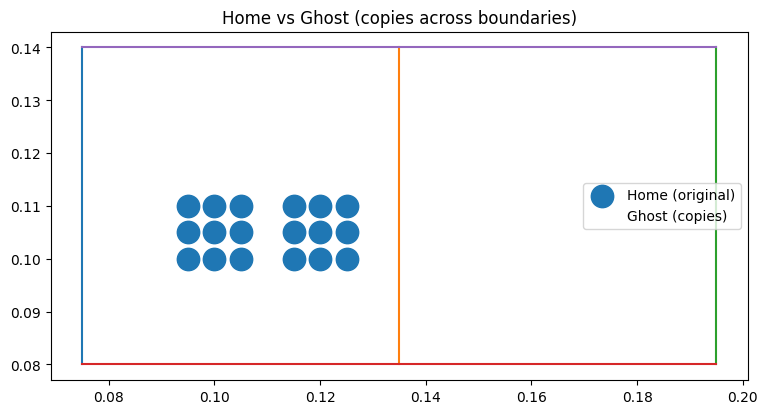

Total emitted records (home + ghosts): 36


In [4]:

def assign_home_and_ghosts(points, cfg):
    out = []

    for pid, x, y in points:
        homeX = int(math.floor((x - cfg.min_x) / cfg.cellSize))
        homeY = int(math.floor((y - cfg.min_y) / cfg.cellSize))

        homeX = max(0, min(homeX, cfg.numCellsX - 1))
        homeY = max(0, min(homeY, cfg.numCellsY - 1))

        homeCellId = cell_id(cfg, homeX, homeY)

        # home record
        out.append((homeCellId, {
            "id": int(pid), "x": float(x), "y": float(y),
            "cellId": int(homeCellId),
            "isLocalRegion": True,
            "clusterId": 0,
            "isCorePoint": False
        }))

        cellMinX = cfg.min_x + homeX * cfg.cellSize
        cellMinY = cfg.min_y + homeY * cfg.cellSize

        dxLeft   = x - cellMinX
        dxRight  = (cellMinX + cfg.cellSize) - x
        dyBottom = y - cellMinY
        dyTop    = (cellMinY + cfg.cellSize) - y

        def add_ghost(cx, cy):
            cid = cell_id(cfg, cx, cy)
            out.append((cid, {
                "id": int(pid), "x": float(x), "y": float(y),
                "cellId": int(cid),
                "isLocalRegion": False,
                "clusterId": 0,
                "isCorePoint": False
            }))

        # 4-neighbors
        if homeX > 0 and dxLeft <= cfg.buffer:
            add_ghost(homeX-1, homeY)
        if homeX < cfg.numCellsX-1 and dxRight <= cfg.buffer:
            add_ghost(homeX+1, homeY)
        if homeY > 0 and dyBottom <= cfg.buffer:
            add_ghost(homeX, homeY-1)
        if homeY < cfg.numCellsY-1 and dyTop <= cfg.buffer:
            add_ghost(homeX, homeY+1)

        # diagonals
        if homeX > 0 and homeY < cfg.numCellsY-1 and dxLeft <= cfg.buffer and dyTop <= cfg.buffer:
            add_ghost(homeX-1, homeY+1)
        if homeX < cfg.numCellsX-1 and homeY < cfg.numCellsY-1 and dxRight <= cfg.buffer and dyTop <= cfg.buffer:
            add_ghost(homeX+1, homeY+1)
        if homeX > 0 and homeY > 0 and dxLeft <= cfg.buffer and dyBottom <= cfg.buffer:
            add_ghost(homeX-1, homeY-1)
        if homeX < cfg.numCellsX-1 and homeY > 0 and dxRight <= cfg.buffer and dyBottom <= cfg.buffer:
            add_ghost(homeX+1, homeY-1)

    return out

assigned = assign_home_and_ghosts(points, cfg)

home  = np.array([(r["x"], r["y"]) for _, r in assigned if r["isLocalRegion"]])
ghost = np.array([(r["x"], r["y"]) for _, r in assigned if not r["isLocalRegion"]])

fig, ax = plt.subplots()
draw_grid(cfg, ax=ax)
ax.scatter(home[:,0], home[:,1], s=260, label="Home (original)")
if len(ghost):
    ax.scatter(ghost[:,0], ghost[:,1], s=360, facecolors="none", linewidths=2, label="Ghost (copies)")
ax.set_title("Home vs Ghost (copies across boundaries)")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

print("Total emitted records (home + ghosts):", len(assigned))



## Step 3 — Group by cell (each cell works independently)

This mimics `partitionedToCellsRDD.groupByKey()`


In [5]:

by_cell = defaultdict(list)
for cid, rec in assigned:
    by_cell[cid].append(rec)

print("Cells that received points:", sorted(by_cell.keys()))
for cid in sorted(by_cell.keys()):
    print(f"Cell {cid}: {len(by_cell[cid])} records (home+ghost)")


Cells that received points: [0, 1]
Cell 0: 18 records (home+ghost)
Cell 1: 18 records (home+ghost)



## Step 4 — Local DBSCAN per cell

This mimics your `localDBSCAN(cellPoints, eps, minPts, ...)`

For small demos we use a smaller `minPts_demo` so clusters form visually.


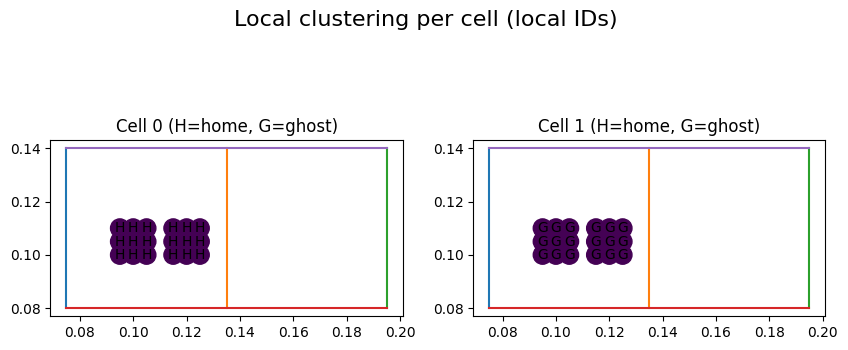

In [6]:

def dist2(a, b):
    dx = a["x"] - b["x"]
    dy = a["y"] - b["y"]
    return dx*dx + dy*dy

def region_query(cell_points, p, eps2):
    return [q for q in cell_points if dist2(p, q) <= eps2]

def expand_cluster(cell_points, p, neighbors, cluster_id, eps2, minPts_demo, visited):
    p["clusterId"] = cluster_id
    seeds = list(neighbors)

    while seeds:
        q = seeds.pop(0)
        if q["id"] not in visited:
            visited.add(q["id"])
            q_neighbors = region_query(cell_points, q, eps2)
            if len(q_neighbors) >= minPts_demo:
                q["isCorePoint"] = True
                for z in q_neighbors:
                    if z not in seeds:
                        seeds.append(z)
        if q["clusterId"] <= 0:
            q["clusterId"] = cluster_id

def local_dbscan_in_cell(cell_points, eps2, minPts_demo):
    visited = set()
    cluster_id = 0
    for p in cell_points:
        if p["id"] in visited:
            continue
        visited.add(p["id"])
        neighbors = region_query(cell_points, p, eps2)
        if len(neighbors) < minPts_demo:
            p["clusterId"] = -1
            p["isCorePoint"] = False
        else:
            cluster_id += 1
            p["isCorePoint"] = True
            expand_cluster(cell_points, p, neighbors, cluster_id, eps2, minPts_demo, visited)

# demo DBSCAN params (presentation-friendly)
eps_demo = 0.03
minPts_demo = 3
eps2 = eps_demo * eps_demo

for cid, cell_points in by_cell.items():
    local_dbscan_in_cell(cell_points, eps2, minPts_demo)

# Visualize local clusters per cell
cell_ids = sorted(by_cell.keys())
n = len(cell_ids)
cols = min(4, n)
rows = (n + cols - 1)//cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.5*rows))
if n == 1:
    axes = np.array([axes])
axes = axes.flatten()

for ax, cid in zip(axes, cell_ids):
    pts = by_cell[cid]
    X = np.array([(p["x"], p["y"]) for p in pts])
    C = np.array([p["clusterId"] for p in pts])

    draw_grid(cfg, ax=ax)
    ax.scatter(X[:,0], X[:,1], s=180, c=C)
    for p in pts:
        label = "H" if p["isLocalRegion"] else "G"
        ax.text(p["x"], p["y"], label, ha="center", va="center", fontsize=10)

    ax.set_title(f"Cell {cid} (H=home, G=ghost)")
    ax.set_aspect("equal", adjustable="box")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Local clustering per cell (local IDs)", fontsize=16)
plt.show()



## Step 5 — Group by point-id and build merge edges

This mimics:
- `groupedByPoint = ... groupByKey()`
- `samePointMergeRDD = groupedByPoint.flatMapToPair(...)`

Each edge connects two **local cluster labels** like `cellId_clusterId`.


In [7]:

# Rebuild a flat list like dbscanClusteredAsPerCellsRDD
clustered_assigned = []
for cid, pts in by_cell.items():
    for r in pts:
        clustered_assigned.append((cid, r))

# groupedByPoint
by_pid = defaultdict(list)
for _, r in clustered_assigned:
    by_pid[r["id"]].append(r)

def build_merge_edges(by_pid, eps2):
    edges = set()
    for pid, copies in by_pid.items():
        if len(copies) < 2:
            continue
        for i in range(len(copies)):
            for j in range(i+1, len(copies)):
                a, b = copies[i], copies[j]

                # mimic Java conditions
                if a["clusterId"] <= 0 or b["clusterId"] <= 0:
                    continue
                if not (a["isCorePoint"] or b["isCorePoint"]):
                    continue
                if dist2(a, b) <= eps2:
                    keyA = f'{a["cellId"]}_{a["clusterId"]}'
                    keyB = f'{b["cellId"]}_{b["clusterId"]}'
                    if keyA != keyB:
                        edges.add((keyA, keyB))
    return sorted(edges)

edges = build_merge_edges(by_pid, eps2)
print("Merge edges (samePointMergeRDD):")
for e in edges:
    print("  ", e)


Merge edges (samePointMergeRDD):
   ('0_1', '1_1')



### Visual: merge edges graph

Nodes are local clusters (`cellId_clusterId`), edges mean “must be merged”.


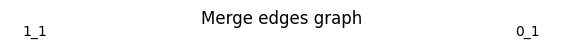

In [8]:

def plot_merge_graph(edges, title="Merge edges graph"):
    nodes = sorted(set([u for u,v in edges] + [v for u,v in edges]))
    if not nodes:
        print("No merge edges in this dataset (nothing to merge).")
        return

    n = len(nodes)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    pos = {nodes[i]:(math.cos(angles[i]), math.sin(angles[i])) for i in range(n)}

    fig, ax = plt.subplots(figsize=(7,6))
    for u,v in edges:
        x1,y1 = pos[u]; x2,y2 = pos[v]
        ax.plot([x1,x2],[y1,y2])

    XY = np.array([pos[k] for k in nodes])
    ax.scatter(XY[:,0], XY[:,1], s=1400)
    for k in nodes:
        x,y = pos[k]
        ax.text(x,y,k, ha="center", va="center", fontsize=10)

    ax.set_title(title)
    ax.axis("off")
    ax.set_aspect("equal", adjustable="box")
    plt.show()

plot_merge_graph(edges)



## Step 6 — Connected Components (GraphX equivalent) → Global cluster ids

This mimics GraphX `ConnectedComponents.run(graph)` using Union-Find.


In [9]:

class UnionFind:
    def __init__(self, items):
        self.parent = {x:x for x in items}
        self.rank = {x:0 for x in items}
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

# allLocalClusters
local_labels = sorted({
    f'{r["cellId"]}_{r["clusterId"]}'
    for _, r in clustered_assigned
    if r["clusterId"] > 0
})

uf = UnionFind(local_labels)
for u, v in edges:
    if u in uf.parent and v in uf.parent:
        uf.union(u, v)

components = defaultdict(list)
for lbl in local_labels:
    components[uf.find(lbl)].append(lbl)

# localToGlobal mapping
local_to_global = {}
for gid, root in enumerate(sorted(components.keys()), start=1):
    for lbl in components[root]:
        local_to_global[lbl] = gid

print("Connected components (each becomes ONE global cluster):")
for root, lbls in components.items():
    print("Component:", root, "->", lbls)

print("\nLocal cluster label -> Global cluster id:")
for k in sorted(local_to_global.keys()):
    print(k, "->", local_to_global[k])


Connected components (each becomes ONE global cluster):
Component: 0_1 -> ['0_1', '1_1']

Local cluster label -> Global cluster id:
0_1 -> 1
1_1 -> 1



## Step 7 — Final output (home points only; ghosts removed)

This mimics:
- `localOnly = ... filter(isLocalRegion)`
- joining to global cluster id


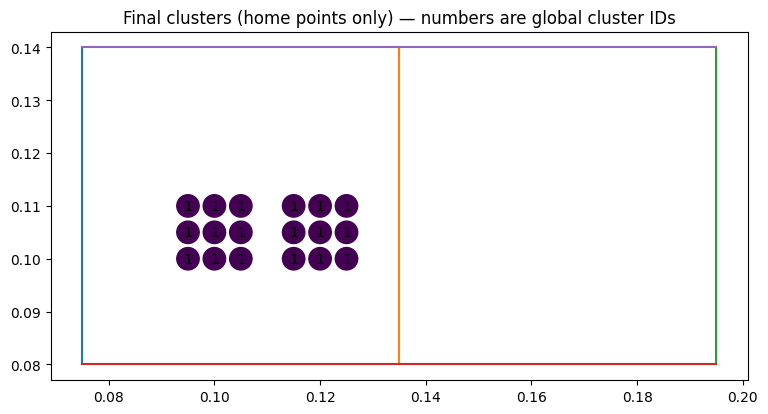

Final (pointId -> globalCluster): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1)]


In [10]:

def assign_final_clusters(clustered_assigned, local_to_global):
    # group all copies by id
    by_pid = defaultdict(list)
    for _, r in clustered_assigned:
        by_pid[r["id"]].append(r)

    final = []
    for pid, copies in by_pid.items():
        home = [c for c in copies if c["isLocalRegion"]]
        if not home:
            continue

        # choose a label: prefer a core-labeled copy, else any labeled copy
        core_key = None
        border_key = None
        for c in copies:
            if c["clusterId"] > 0:
                k = f'{c["cellId"]}_{c["clusterId"]}'
                if c["isCorePoint"]:
                    core_key = k
                else:
                    border_key = k

        chosen = core_key if core_key is not None else border_key
        global_id = local_to_global.get(chosen, -1) if chosen is not None else -1

        out = dict(home[0])  # output home record only
        out["globalCluster"] = global_id
        final.append(out)

    return final

final_points = assign_final_clusters(clustered_assigned, local_to_global)

# final plot
X = np.array([(p["x"], p["y"]) for p in final_points])
G = np.array([p["globalCluster"] for p in final_points])

fig, ax = plt.subplots()
draw_grid(cfg, ax=ax)
ax.scatter(X[:,0], X[:,1], s=260, c=G)
for p in final_points:
    ax.text(p["x"], p["y"], str(int(p["globalCluster"])), ha="center", va="center", fontsize=10)
ax.set_title("Final clusters (home points only) — numbers are global cluster IDs")
ax.set_aspect("equal", adjustable="box")
plt.show()

print("Final (pointId -> globalCluster):", [(p["id"], p["globalCluster"]) for p in final_points])
